In [3]:
%pip install rasterio matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 443.4 kB/s eta 0:00:0000:0100:02
Note: you may need to restart the kernel to use updated packages.


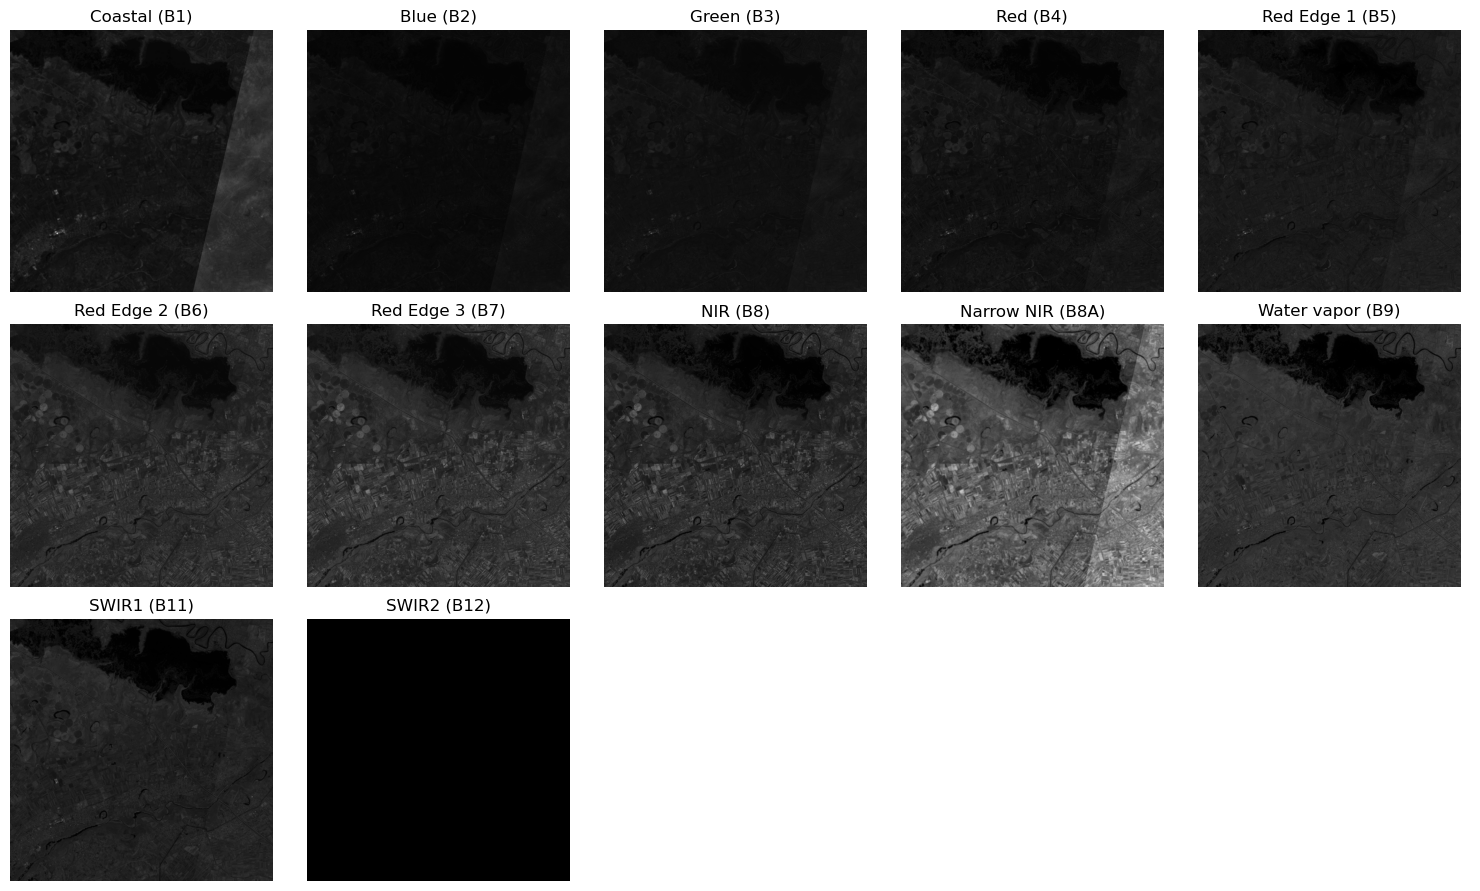

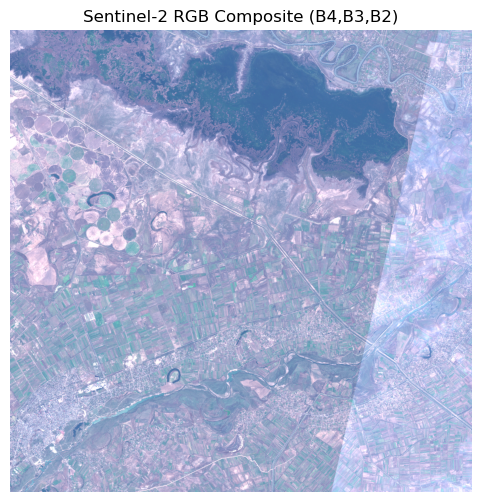

In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = "allbands.tiff"

# Open the TIFF
with rasterio.open(file_path) as src:
    bands = src.read()   # (bands, height, width)
    num_bands = bands.shape[0]

band_names = [
    "Coastal (B1)", "Blue (B2)", "Green (B3)", "Red (B4)", "Red Edge 1 (B5)",
    "Red Edge 2 (B6)", "Red Edge 3 (B7)", "NIR (B8)", "Narrow NIR (B8A)",
    "Water vapor (B9)", "SWIR1 (B11)", "SWIR2 (B12)"
]


cols = 5
rows = int(np.ceil(num_bands / cols))


fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

for i in range(rows*cols):
    ax = axes[i]
    if i < num_bands:
        ax.imshow(bands[i], cmap='gray')
        if i < len(band_names):
            ax.set_title(band_names[i])
        else:
            ax.set_title(f'Band {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()


if num_bands >= 4:
    red = bands[3]    
    green = bands[2]  
    blue = bands[1]   

    rgb = np.dstack((red, green, blue)).astype(float)
    rgb /= np.percentile(rgb, 98)  # contrast stretch
    rgb = np.clip(rgb, 0, 1)



    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title("Sentinel-2 RGB Composite (B4,B3,B2)")
    plt.axis('off')
    plt.show()